
# WF03 — NBR/dNBR Burned-Area Baseline

## Objective
Investigate whether pre-fire and post-fire Sentinel-2 imagery show spectral changes consistent with burned areas.

## Research questions
1. Can the Normalized Burn Ratio (NBR) reveal changes after a documented wildfire?
2. How does differenced NBR (dNBR) vary across the study area?
3. How sensitive are candidate burned-area estimates to different dNBR thresholds?
4. Which limitations prevent us from treating these estimates as verified burned areas?

## Satellite data
- Source: Sentinel-2 Level-2A surface reflectance
- B08: near-infrared (NIR)
- B12: short-wave infrared (SWIR2)
- SCL: scene classification layer for masking clouds and other unsuitable pixels

## Indices
NBR = (B08 - B12) / (B08 + B12)

dNBR = NBR_before - NBR_after

Positive dNBR can indicate a decrease in vegetation-related spectral response after a fire. It is not, by itself, proof of burned land.

## Pilot event
The Lahaina, Hawaii wildfire, August 2023, is the initial candidate event. We will verify that suitable pre-fire and post-fire scenes are available before interpreting results.

## Important limitations
- Clouds, cloud shadows, smoke, buildings, bare soil, and other land-cover changes can affect the index.
- Scene dates and cloud masking must be documented.
- Thresholds are exploratory unless independently validated.
- A spectral-change map is not the same as an independently verified burn perimeter.

In [1]:

# Install the libraries required for satellite imagery search,
# image loading, geospatial processing, and visualization.

%pip install -q pystac-client planetary-computer stackstac rasterio rioxarray scipy matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.7 MB/s eta 0:00:00


In [2]:

# Import Python libraries.
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

from rasterio.enums import Resampling
from pystac_client import Client
import planetary_computer
import stackstac
import rioxarray  # Registers the .rio accessor used for GeoTIFF export.

from IPython.display import display

# Define the main working directory in Google Colab.
BASE_DIR = Path("/content/wildfire_monitoring")

# Keep input metadata and outputs separate.
DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
WF03_DATA_DIR = DATA_DIR / "WF03_sentinel2"
WF03_RESULTS_DIR = RESULTS_DIR / "WF03_nbr_dnbr"

# Create folders if they do not already exist.
for folder in [DATA_DIR, RESULTS_DIR, WF03_DATA_DIR, WF03_RESULTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Record the notebook's configuration for reproducibility.
print("WF03 folders are ready.")
print("Data folder:", WF03_DATA_DIR)
print("Results folder:", WF03_RESULTS_DIR)

WF03 folders are ready.
Data folder: /content/wildfire_monitoring/data/WF03_sentinel2
Results folder: /content/wildfire_monitoring/results/WF03_nbr_dnbr


In [3]:

# Approximate pilot location around Lahaina, Maui, Hawaii.
# Coordinates are longitude/latitude in decimal degrees.
# This bounding box is a study window, NOT an official burn perimeter.

EVENT_NAME = "Lahaina_Hawaii_2023"
EVENT_START_DATE = "2023-08-08"
EVENT_END_DATE = "2023-08-09"

# Bounding box format: [minimum longitude, minimum latitude,
#                       maximum longitude, maximum latitude]
AOI_BBOX = [-156.75, 20.80, -156.60, 20.95]

# Search separate windows before and after the event.
# These windows may be adjusted if no suitable scenes are found.
PRE_FIRE_DATES = "2023-07-15/2023-08-07"
POST_FIRE_DATES = "2023-08-10/2023-09-15"

# Maximum scene-wide cloud-cover percentage allowed for initial search.
# This is a search filter, not a guarantee that the AOI itself is cloud-free.
MAX_SCENE_CLOUD_PERCENT = 80

# Sentinel-2 tiles covering Maui use UTM zone 5N.
OUTPUT_EPSG = 32605

# Save the experiment configuration.
config = {
    "event_name": EVENT_NAME,
    "event_start_date": EVENT_START_DATE,
    "event_end_date": EVENT_END_DATE,
    "aoi_bbox_lon_lat": AOI_BBOX,
    "pre_fire_date_window": PRE_FIRE_DATES,
    "post_fire_date_window": POST_FIRE_DATES,
    "maximum_scene_cloud_cover_percent": MAX_SCENE_CLOUD_PERCENT,
    "output_epsg": OUTPUT_EPSG,
    "satellite_collection": "sentinel-2-l2a",
    "bands": ["B08", "B12", "SCL"]
}

config_path = WF03_RESULTS_DIR / "WF03_configuration.json"
with open(config_path, "w", encoding="utf-8") as file:
    json.dump(config, file, indent=2)

print("Pilot event:", EVENT_NAME)
print("AOI bounding box:", AOI_BBOX)
print("Pre-fire search:", PRE_FIRE_DATES)
print("Post-fire search:", POST_FIRE_DATES)
print("Configuration saved:", config_path)

Pilot event: Lahaina_Hawaii_2023
AOI bounding box: [-156.75, 20.8, -156.6, 20.95]
Pre-fire search: 2023-07-15/2023-08-07
Post-fire search: 2023-08-10/2023-09-15
Configuration saved: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_configuration.json


In [4]:

# Connect to the public STAC catalogue.
STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"

catalog = Client.open(STAC_URL)

def search_sentinel_scenes(date_window, bbox, max_cloud_percent):
    """
    Search Sentinel-2 Level-2A scenes for a bounding box and date window.

    The catalogue's cloud-cover property describes the whole scene.
    It does not guarantee cloud-free pixels inside our smaller study area.
    """
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=date_window,
        query={
            "eo:cloud_cover": {"lt": max_cloud_percent}
        },
        max_items=100
    )

    items = list(search.items())

    # Sort scenes from lowest to highest reported scene-wide cloud cover.
    items.sort(
        key=lambda item: item.properties.get("eo:cloud_cover", 100)
    )
    return items

pre_items = search_sentinel_scenes(
    PRE_FIRE_DATES, AOI_BBOX, MAX_SCENE_CLOUD_PERCENT
)

post_items = search_sentinel_scenes(
    POST_FIRE_DATES, AOI_BBOX, MAX_SCENE_CLOUD_PERCENT
)

print("Pre-fire scenes found:", len(pre_items))
print("Post-fire scenes found:", len(post_items))

def scenes_to_table(items, period_name):
    """Create a readable table of candidate scene metadata."""
    rows = []
    for item in items:
        rows.append({
            "period": period_name,
            "item_id": item.id,
            "datetime_utc": str(item.datetime),
            "scene_cloud_cover_percent": item.properties.get("eo:cloud_cover"),
            "platform": item.properties.get("platform"),
            "assets_available": ", ".join(sorted(item.assets.keys()))
        })
    return pd.DataFrame(rows)

pre_scene_table = scenes_to_table(pre_items, "pre-fire")
post_scene_table = scenes_to_table(post_items, "post-fire")

scene_table = pd.concat(
    [pre_scene_table, post_scene_table],
    ignore_index=True
)

if not scene_table.empty:
    display(scene_table)
    scene_table.to_csv(
        WF03_RESULTS_DIR / "WF03_candidate_scenes.csv",
        index=False
    )
else:
    print("No scenes matched the initial search. Do not proceed to image loading.")
    print("We must inspect the date windows, bounding box, and catalogue response.")

Pre-fire scenes found: 5
Post-fire scenes found: 10


,period,item_id,datetime_utc,scene_cloud_cover_percent,platform,assets_available
0,pre-fire,S2A_MSIL2A_20230803T210931_R057_T04QGJ_2024082...,2023-08-03 21:09:31.024000+00:00,4.297092,Sentinel-2A,"AOT, B01, B02, B03, B04, B05, B06, B07, B08, B..."
1,pre-fire,S2A_MSIL2A_20230803T210931_R057_T04QGJ_2023080...,2023-08-03 21:09:31.024000+00:00,5.951221,Sentinel-2A,"AOT, B01, B02, B03, B04, B05, B06, B07, B08, B..."
2,pre-fire,S2A_MSIL2A_20230724T210931_R057_T04QGJ_2023072...,2023-07-24 21:09:31.024000+00:00,8.159262,Sentinel-2A,"AOT, B01, B02, B03, B04, B05, B06, B07, B08, B..."
3,pre-fire,S2B_MSIL2A_20230729T210929_R057_T04QGJ_2024082...,2023-07-29 21:09:29.024000+00:00,16.376172,Sentinel-2B,"AOT, B01, B02, B03, B04, B05, B06, B07, B08, B..."
4,pre-fire,S2B_MSIL2A_20230729T210929_R057_T04QGJ_2023073...,2023-07-29 21:09:29.024000+00:00,18.124950,Sentinel-2B,"AOT, B01, B02, B03, B04, B05, B06, B07, B08, B..."
5,post-fire,S2B_MSIL2A_20230907T210929_R057_T04QGJ_2023090...,2023-09-07 21:09:29.024000+00:00,6.068676,Sentinel-2B,"AOT, B01, B02, B03, B04, B05, B06, B07, B08, B..."
6,post-fire,S2A_MSIL2A_20230813T210931_R057_T04QGJ_2023081...,2023-08-13 21:09:31.024000+00:00,6.739990,Sentinel-2A,"AOT, B01, B02, B03, B04, B05, B06, B07, B08, B..."
7,post-fire,S2B_MSIL2A_20230818T210929_R057_T04QGJ_2023081...,2023-08-18 21:09:29.024000+00:00,8.564159,Sentinel-2B,"AOT, B01, B02, B03, B04, B05, B06, B07, B08, B..."
8,post-fire,S2A_MSIL2A_20230823T210931_R057_T04QGJ_2023082...,2023-08-23 21:09:31.024000+00:00,11.949220,Sentinel-2A,"AOT, B01, B02, B03, B04, B05, B06, B07, B08, B..."
9,post-fire,S2B_MSIL2A_20230828T210929_R057_T04QGJ_2024082...,2023-08-28 21:09:29.024000+00:00,18.926354,Sentinel-2B,"AOT, B01, B02, B03, B04, B05, B06, B07, B08, B..."


In [5]:

# Stop safely if the catalogue returned no scene for either period.
if len(pre_items) == 0:
    raise RuntimeError(
        "No pre-fire Sentinel-2 scene found. Adjust PRE_FIRE_DATES or AOI_BBOX."
    )

if len(post_items) == 0:
    raise RuntimeError(
        "No post-fire Sentinel-2 scene found. Adjust POST_FIRE_DATES or AOI_BBOX."
    )

# The search results are already sorted by reported cloud cover.
pre_item = pre_items[0]
post_item = post_items[0]

# Confirm that the requested spectral assets exist.
required_assets = ["B08", "B12", "SCL"]

for period_name, item in [
    ("pre-fire", pre_item),
    ("post-fire", post_item)
]:
    missing_assets = [
        asset for asset in required_assets
        if asset not in item.assets
    ]

    if missing_assets:
        raise KeyError(
            f"{period_name} scene {item.id} is missing assets: {missing_assets}"
        )

# Display the selected scenes for reproducibility.
selected_scenes = pd.DataFrame([
    {
        "period": "pre-fire",
        "item_id": pre_item.id,
        "datetime_utc": str(pre_item.datetime),
        "scene_cloud_cover_percent": pre_item.properties.get("eo:cloud_cover")
    },
    {
        "period": "post-fire",
        "item_id": post_item.id,
        "datetime_utc": str(post_item.datetime),
        "scene_cloud_cover_percent": post_item.properties.get("eo:cloud_cover")
    }
])

display(selected_scenes)

selected_scenes.to_csv(
    WF03_RESULTS_DIR / "WF03_selected_scenes.csv",
    index=False
)

# Save the full selected item identifiers.
with open(
    WF03_RESULTS_DIR / "WF03_selected_scene_ids.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(f"Pre-fire item: {pre_item.id}\n")
    file.write(f"Pre-fire datetime: {pre_item.datetime}\n")
    file.write(f"Post-fire item: {post_item.id}\n")
    file.write(f"Post-fire datetime: {post_item.datetime}\n")

print("Selected scene metadata saved.")

,period,item_id,datetime_utc,scene_cloud_cover_percent
0,pre-fire,S2A_MSIL2A_20230803T210931_R057_T04QGJ_2024082...,2023-08-03 21:09:31.024000+00:00,4.297092
1,post-fire,S2B_MSIL2A_20230907T210929_R057_T04QGJ_2023090...,2023-09-07 21:09:29.024000+00:00,6.068676


Selected scene metadata saved.


In [6]:

def load_sentinel_bands(item, period_name):
    """
    Load B08, B12, and SCL for one selected Sentinel-2 scene.

    All bands are placed on the same 20 m grid.
    Nearest-neighbour resampling is used for the categorical SCL band.
    """
    print(f"Loading {period_name} scene:", item.id)

    # Sign the item so its cloud-hosted image assets can be accessed.
    signed_item = planetary_computer.sign(item)

    image_stack = stackstac.stack(
        [signed_item],
        assets=["B08", "B12", "SCL"],
        resolution=20,
        epsg=OUTPUT_EPSG,
        bounds_latlon=AOI_BBOX,
        resampling=Resampling.nearest,
        xy_coords="center"
    )

    # Load the small selected area into Colab memory.
    image_stack = image_stack.compute()

    # Remove the single-scene time dimension and extract each band.
    band_data = image_stack.isel(time=0)

    b08 = band_data.sel(band="B08").values.astype("float32")
    b12 = band_data.sel(band="B12").values.astype("float32")
    scl = band_data.sel(band="SCL").values.astype("float32")

    # Preserve the geospatial coordinates for later GeoTIFF export.
    spatial_template = band_data.sel(band="B08").astype("float32")

    print(f"{period_name} array shape:", b08.shape)
    print(f"{period_name} B08 finite pixels:", int(np.isfinite(b08).sum()))
    print(f"{period_name} B12 finite pixels:", int(np.isfinite(b12).sum()))
    print(f"{period_name} SCL finite pixels:", int(np.isfinite(scl).sum()))

    return {
        "B08": b08,
        "B12": b12,
        "SCL": scl,
        "template": spatial_template,
        "item_id": item.id,
        "datetime": str(item.datetime)
    }

pre_data = load_sentinel_bands(pre_item, "pre-fire")
post_data = load_sentinel_bands(post_item, "post-fire")

# Confirm that each scene's bands align internally.
assert pre_data["B08"].shape == pre_data["B12"].shape == pre_data["SCL"].shape
assert post_data["B08"].shape == post_data["B12"].shape == post_data["SCL"].shape

# The two periods must also share the same grid for pixel-wise differencing.
assert pre_data["B08"].shape == post_data["B08"].shape, (
    "Pre-fire and post-fire arrays have different shapes. "
    "Do not calculate dNBR until the grids are aligned."
)

print("Band loading and array-shape checks passed.")

Loading pre-fire scene: S2A_MSIL2A_20230803T210931_R057_T04QGJ_20240823T144936


pre-fire array shape: (851, 801)
pre-fire B08 finite pixels: 681651
pre-fire B12 finite pixels: 681651
pre-fire SCL finite pixels: 681651
Loading post-fire scene: S2B_MSIL2A_20230907T210929_R057_T04QGJ_20230908T042719


post-fire array shape: (851, 801)
post-fire B08 finite pixels: 681650
post-fire B12 finite pixels: 681651
post-fire SCL finite pixels: 681651
Band loading and array-shape checks passed.


In [7]:

# Cell 9: Create valid-pixel masks.
# SCL classes retained for this baseline:
# 2 = dark area, 4 = vegetation, 5 = bare soil, 6 = water.
# All other classes are excluded from the NBR calculation.

VALID_SCL_CLASSES = [2, 4, 5, 6]

def create_valid_mask(scene_data):
    """Combine valid reflectance pixels with acceptable SCL categories."""
    b08 = scene_data["B08"]
    b12 = scene_data["B12"]
    scl = scene_data["SCL"]

    finite_bands = np.isfinite(b08) & np.isfinite(b12) & np.isfinite(scl)
    acceptable_scl = np.isin(scl, VALID_SCL_CLASSES)

    # Reflectance should not be negative in the scaled values used here.
    # Zero values are not automatically rejected; denominator checks follow.
    nonnegative_bands = (b08 >= 0) & (b12 >= 0)

    return finite_bands & acceptable_scl & nonnegative_bands

pre_valid_mask = create_valid_mask(pre_data)
post_valid_mask = create_valid_mask(post_data)

# A pixel is valid for change analysis only if both dates are suitable.
common_valid_mask = pre_valid_mask & post_valid_mask

total_pixels = common_valid_mask.size
common_valid_count = int(common_valid_mask.sum())

print("Total pixels in study grid:", total_pixels)
print("Valid on both dates:", common_valid_count)
print("Valid on both dates (%):", round(100 * common_valid_count / total_pixels, 2))

# Save a record of the pixel-mask coverage.
mask_report = pd.DataFrame([{
    "total_pixels": total_pixels,
    "pre_valid_pixels": int(pre_valid_mask.sum()),
    "post_valid_pixels": int(post_valid_mask.sum()),
    "common_valid_pixels": common_valid_count,
    "common_valid_percent": 100 * common_valid_count / total_pixels
}])

mask_report.to_csv(
    WF03_RESULTS_DIR / "WF03_valid_pixel_summary.csv",
    index=False
)

if common_valid_count == 0:
    raise ValueError(
        "No pixels are valid on both dates. Inspect SCL values, "
        "scene selection, and grid alignment before proceeding."
    )

Total pixels in study grid: 681651
Valid on both dates: 398857
Valid on both dates (%): 58.51


In [8]:

# Cell 10: Calculate NBR for both dates.
# The Sentinel-2 reflectance scaling factor cancels in this ratio,
# provided both bands use the same scaling convention.

def calculate_nbr(nir, swir2):
    """Calculate NBR safely, returning NaN where the denominator is zero."""
    denominator = nir + swir2

    nbr = np.full(nir.shape, np.nan, dtype=np.float32)

    safe = (
        np.isfinite(nir)
        & np.isfinite(swir2)
        & np.isfinite(denominator)
        & (denominator != 0)
    )

    nbr[safe] = (nir[safe] - swir2[safe]) / denominator[safe]
    return nbr

pre_nbr = calculate_nbr(pre_data["B08"], pre_data["B12"])
post_nbr = calculate_nbr(post_data["B08"], post_data["B12"])

# Remove pixels that were invalid in either date.
pre_nbr[~common_valid_mask] = np.nan
post_nbr[~common_valid_mask] = np.nan

print("Pre-fire NBR range:", np.nanmin(pre_nbr), "to", np.nanmax(pre_nbr))
print("Post-fire NBR range:", np.nanmin(post_nbr), "to", np.nanmax(post_nbr))
print("Valid pre-fire NBR pixels:", int(np.isfinite(pre_nbr).sum()))
print("Valid post-fire NBR pixels:", int(np.isfinite(post_nbr).sum()))

# NBR is theoretically bounded between -1 and +1 for nonnegative inputs.
# Values outside this range would warrant investigation.
for label, array in [("pre-fire", pre_nbr), ("post-fire", post_nbr)]:
    finite_values = array[np.isfinite(array)]
    if finite_values.size and (
        finite_values.min() < -1.001 or finite_values.max() > 1.001
    ):
        warnings.warn(f"{label} NBR contains values outside the expected range.")

# Export each NBR layer as a georeferenced GeoTIFF.
pre_nbr_da = pre_data["template"].copy(data=pre_nbr)
post_nbr_da = post_data["template"].copy(data=post_nbr)

pre_nbr_da.rio.write_nodata(np.nan, inplace=True)
post_nbr_da.rio.write_nodata(np.nan, inplace=True)

pre_nbr_path = WF03_RESULTS_DIR / "WF03_pre_fire_NBR.tif"
post_nbr_path = WF03_RESULTS_DIR / "WF03_post_fire_NBR.tif"

pre_nbr_da.rio.to_raster(pre_nbr_path)
post_nbr_da.rio.to_raster(post_nbr_path)

print("Saved:", pre_nbr_path)
print("Saved:", post_nbr_path)

Pre-fire NBR range: -0.42255005 to 0.6228329
Post-fire NBR range: -0.44268954 to 0.6062176
Valid pre-fire NBR pixels: 398857
Valid post-fire NBR pixels: 398857
Saved: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_pre_fire_NBR.tif
Saved: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_post_fire_NBR.tif


In [9]:

# Cell 11: Calculate differenced NBR (dNBR).
# Positive values indicate that pre-fire NBR was higher than post-fire NBR.

dnbr = pre_nbr - post_nbr
dnbr[~common_valid_mask] = np.nan

finite_dnbr = dnbr[np.isfinite(dnbr)]

if finite_dnbr.size == 0:
    raise ValueError("No valid dNBR pixels are available.")

dnbr_summary = pd.DataFrame([{
    "valid_pixels": int(finite_dnbr.size),
    "minimum_dnbr": float(np.min(finite_dnbr)),
    "maximum_dnbr": float(np.max(finite_dnbr)),
    "mean_dnbr": float(np.mean(finite_dnbr)),
    "median_dnbr": float(np.median(finite_dnbr)),
    "std_dnbr": float(np.std(finite_dnbr))
}])

display(dnbr_summary)

dnbr_summary.to_csv(
    WF03_RESULTS_DIR / "WF03_dnbr_summary.csv",
    index=False
)

dnbr_da = pre_data["template"].copy(data=dnbr)
dnbr_da.rio.write_nodata(np.nan, inplace=True)

dnbr_path = WF03_RESULTS_DIR / "WF03_dNBR.tif"
dnbr_da.rio.to_raster(dnbr_path)

print("Saved dNBR raster:", dnbr_path)

,valid_pixels,minimum_dnbr,maximum_dnbr,mean_dnbr,median_dnbr,std_dnbr
0,398857,-0.482351,0.6275,0.03663,0.02566,0.055734


Saved dNBR raster: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_dNBR.tif


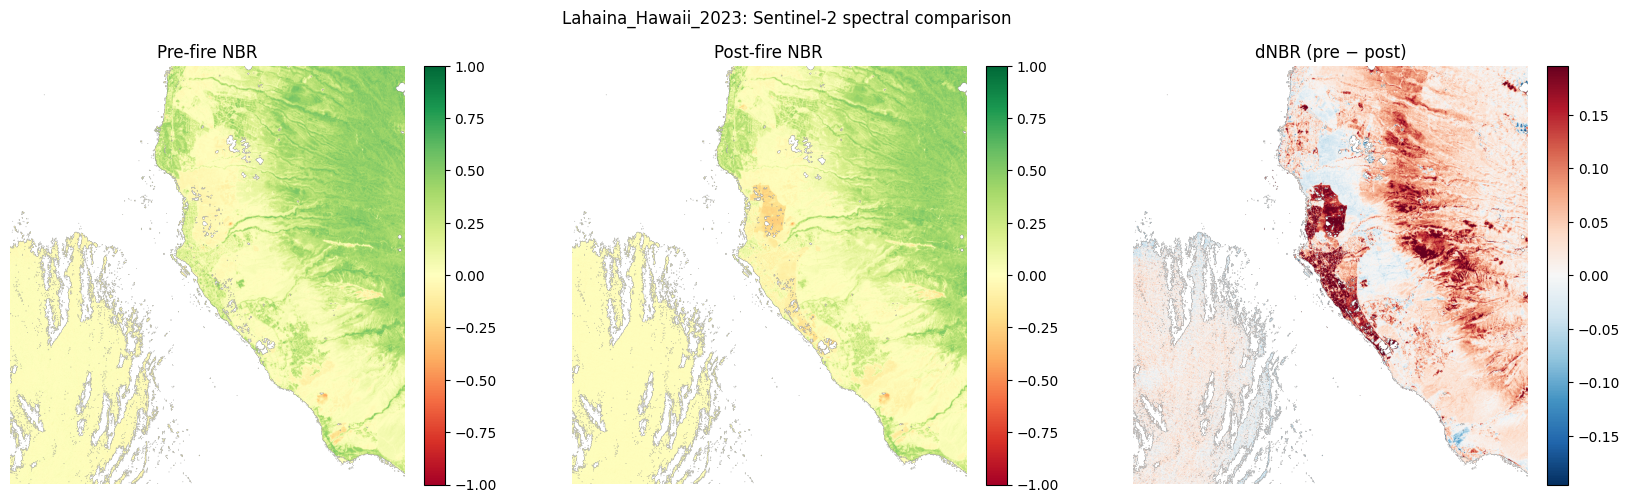

Saved visualization: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_NBR_dNBR_visualization.png


In [10]:

# Cell 12: Plot the three index layers side by side.
# These are exploratory visualizations, not verified burn-perimeter maps.

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

im0 = axes[0].imshow(pre_nbr, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0].set_title("Pre-fire NBR")
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(post_nbr, cmap="RdYlGn", vmin=-1, vmax=1)
axes[1].set_title("Post-fire NBR")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Use a symmetric color range to show negative and positive changes.
dnbr_limit = max(
    abs(float(np.nanpercentile(dnbr, 2))),
    abs(float(np.nanpercentile(dnbr, 98))),
    0.1
)

im2 = axes[2].imshow(
    dnbr,
    cmap="RdBu_r",
    vmin=-dnbr_limit,
    vmax=dnbr_limit
)
axes[2].set_title("dNBR (pre − post)")
axes[2].axis("off")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

fig.suptitle(f"{EVENT_NAME}: Sentinel-2 spectral comparison")
plt.tight_layout()

figure_path = WF03_RESULTS_DIR / "WF03_NBR_dNBR_visualization.png"
plt.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved visualization:", figure_path)

In [12]:

# Cell 13: Exploratory dNBR threshold sensitivity analysis.
#
# Purpose:
# Compare how different dNBR thresholds change the estimated area
# of pixels showing possible fire-related spectral change.
#
# Important:
# These are exploratory thresholds, not validated universal
# burned-area thresholds. Candidate pixels are NOT confirmed burns.

DNBR_THRESHOLDS = [0.10, 0.20, 0.30, 0.40]

# Identify pixels where dNBR is a valid number.
valid_dnbr = np.isfinite(dnbr)
valid_pixel_count = int(valid_dnbr.sum())

if valid_pixel_count == 0:
    raise ValueError(
        "No valid dNBR pixels found. Check Cells 9–11 before continuing."
    )

threshold_rows = []

for threshold in DNBR_THRESHOLDS:

    # Select valid pixels whose dNBR meets the current threshold.
    candidate_mask = valid_dnbr & (dnbr >= threshold)

    # Count candidate pixels.
    candidate_count = int(candidate_mask.sum())

    # Calculate the share of valid pixels selected.
    candidate_percent = 100 * candidate_count / valid_pixel_count

    # Approximate area for a 20 m x 20 m grid.
    # 20 m * 20 m = 400 m²; 1 km² = 1,000,000 m².
    candidate_area_km2 = candidate_count * 400 / 1_000_000

    threshold_rows.append({
        "dnbr_threshold": threshold,
        "valid_pixels": valid_pixel_count,
        "candidate_pixels": candidate_count,
        "candidate_percent_of_valid_area": candidate_percent,
        "candidate_area_km2_approx": candidate_area_km2
    })

# Create and display the results table.
threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

# Save the results for the research report.
threshold_csv = WF03_RESULTS_DIR / "WF03_threshold_sensitivity.csv"
threshold_df.to_csv(threshold_csv, index=False)

print("Threshold sensitivity analysis completed.")
print("Saved results to:", threshold_csv)
print("Reminder: these are candidate spectral-change areas, not verified burned areas.")

,dnbr_threshold,valid_pixels,candidate_pixels,candidate_percent_of_valid_area,candidate_area_km2_approx
0,0.1,398857,41529,10.412002,16.6116
1,0.2,398857,7332,1.838253,2.9328
2,0.3,398857,1467,0.367801,0.5868
3,0.4,398857,388,0.097278,0.1552


Threshold sensitivity analysis completed.
Saved results to: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_threshold_sensitivity.csv
Reminder: these are candidate spectral-change areas, not verified burned areas.


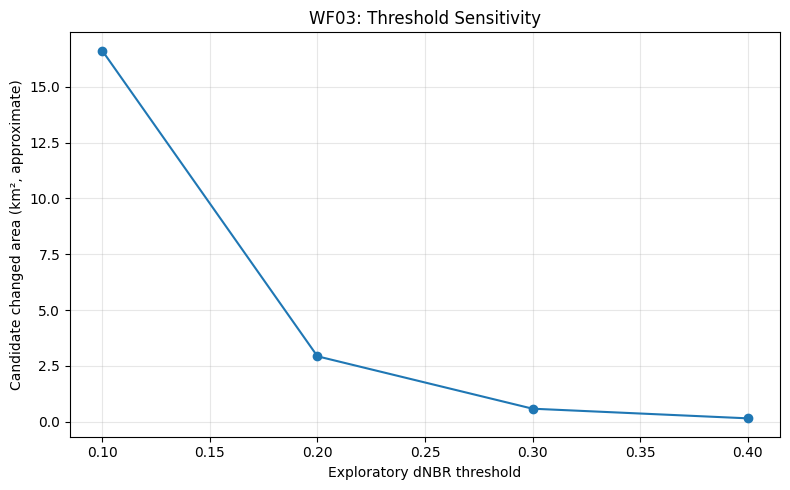

Saved threshold plot: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_threshold_sensitivity.png


In [13]:

# Cell 14: Show how candidate area changes as the threshold increases.

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    threshold_df["dnbr_threshold"],
    threshold_df["candidate_area_km2_approx"],
    marker="o"
)

ax.set_xlabel("Exploratory dNBR threshold")
ax.set_ylabel("Candidate changed area (km², approximate)")
ax.set_title("WF03: Threshold Sensitivity")
ax.grid(True, alpha=0.3)

plt.tight_layout()

threshold_plot = WF03_RESULTS_DIR / "WF03_threshold_sensitivity.png"
plt.savefig(threshold_plot, dpi=200, bbox_inches="tight")
plt.show()

print("Saved threshold plot:", threshold_plot)

In [14]:

# Cell 15: Export one binary candidate map per threshold.
# 1 = candidate spectral change; 0 = valid pixel below threshold.
# Invalid pixels are saved as NoData (255).

for threshold in DNBR_THRESHOLDS:
    candidate_mask = np.zeros(dnbr.shape, dtype=np.uint8)
    candidate_mask[valid_dnbr & (dnbr >= threshold)] = 1

    # Encode invalid pixels separately so they are not confused with negatives.
    candidate_mask[~valid_dnbr] = 255

    candidate_da = pre_data["template"].copy(data=candidate_mask)
    candidate_da = candidate_da.rio.write_nodata(255, inplace=False)

    threshold_label = str(threshold).replace(".", "p")
    output_path = (
        WF03_RESULTS_DIR / f"WF03_candidate_change_{threshold_label}.tif"
    )

    candidate_da.rio.to_raster(output_path)
    print("Saved:", output_path)

Saved: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_candidate_change_0p1.tif
Saved: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_candidate_change_0p2.tif
Saved: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_candidate_change_0p3.tif
Saved: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_candidate_change_0p4.tif


In [15]:

# Cell 16: Document scene dates and valid-pixel coverage.

pre_date = pd.Timestamp(pre_item.datetime)
post_date = pd.Timestamp(post_item.datetime)

date_gap_days = abs((post_date - pre_date).days)

coverage_record = {
    "event_name": EVENT_NAME,
    "pre_fire_scene_id": pre_item.id,
    "pre_fire_datetime": str(pre_item.datetime),
    "pre_fire_cloud_cover_percent": pre_item.properties.get("eo:cloud_cover"),
    "post_fire_scene_id": post_item.id,
    "post_fire_datetime": str(post_item.datetime),
    "post_fire_cloud_cover_percent": post_item.properties.get("eo:cloud_cover"),
    "days_between_selected_scenes": date_gap_days,
    "common_valid_pixels": int(common_valid_mask.sum()),
    "total_grid_pixels": int(common_valid_mask.size),
    "common_valid_percent": float(100 * common_valid_mask.mean())
}

coverage_df = pd.DataFrame([coverage_record])
display(coverage_df)

coverage_path = WF03_RESULTS_DIR / "WF03_scene_and_coverage_summary.csv"
coverage_df.to_csv(coverage_path, index=False)

print("Saved scene and coverage summary:", coverage_path)

,event_name,pre_fire_scene_id,pre_fire_datetime,pre_fire_cloud_cover_percent,post_fire_scene_id,post_fire_datetime,post_fire_cloud_cover_percent,days_between_selected_scenes,common_valid_pixels,total_grid_pixels,common_valid_percent
0,Lahaina_Hawaii_2023,S2A_MSIL2A_20230803T210931_R057_T04QGJ_2024082...,2023-08-03 21:09:31.024000+00:00,4.297092,S2B_MSIL2A_20230907T210929_R057_T04QGJ_2023090...,2023-09-07 21:09:29.024000+00:00,6.068676,34,398857,681651,58.513374


Saved scene and coverage summary: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_scene_and_coverage_summary.csv


In [16]:

# Cell 17: Verify that the expected artifacts exist and are non-empty.

expected_outputs = [
    "WF03_configuration.json",
    "WF03_candidate_scenes.csv",
    "WF03_selected_scenes.csv",
    "WF03_selected_scene_ids.txt",
    "WF03_scl_class_distribution.csv",
    "WF03_valid_pixel_summary.csv",
    "WF03_pre_fire_NBR.tif",
    "WF03_post_fire_NBR.tif",
    "WF03_dnbr_summary.csv",
    "WF03_dNBR.tif",
    "WF03_NBR_dNBR_visualization.png",
    "WF03_threshold_sensitivity.csv",
    "WF03_threshold_sensitivity.png",
    "WF03_candidate_change_0p10.tif",
    "WF03_candidate_change_0p20.tif",
    "WF03_candidate_change_0p30.tif",
    "WF03_candidate_change_0p40.tif",
    "WF03_scene_and_coverage_summary.csv"
]

verification_rows = []

for filename in expected_outputs:
    path = WF03_RESULTS_DIR / filename
    exists = path.is_file()
    size_bytes = path.stat().st_size if exists else 0

    verification_rows.append({
        "filename": filename,
        "exists": exists,
        "size_bytes": size_bytes,
        "non_empty": bool(exists and size_bytes > 0)
    })

verification_df = pd.DataFrame(verification_rows)
display(verification_df)

verification_path = WF03_RESULTS_DIR / "WF03_output_verification.csv"
verification_df.to_csv(verification_path, index=False)

missing = verification_df.loc[
    ~verification_df["non_empty"], "filename"
].tolist()

if missing:
    print("Some outputs are missing or empty:")
    for filename in missing:
        print("-", filename)
else:
    print("All expected WF03 output files exist and are non-empty.")

,filename,exists,size_bytes,non_empty
0,WF03_configuration.json,True,449,True
1,WF03_candidate_scenes.csv,True,4970,True
2,WF03_selected_scenes.csv,True,267,True
3,WF03_selected_scene_ids.txt,True,246,True
4,WF03_scl_class_distribution.csv,False,0,False
5,WF03_valid_pixel_summary.csv,True,136,True
6,WF03_pre_fire_NBR.tif,True,2729837,True
7,WF03_post_fire_NBR.tif,True,2729837,True
8,WF03_dnbr_summary.csv,True,178,True
9,WF03_dNBR.tif,True,2729837,True


Some outputs are missing or empty:
- WF03_scl_class_distribution.csv
- WF03_candidate_change_0p10.tif
- WF03_candidate_change_0p20.tif
- WF03_candidate_change_0p30.tif
- WF03_candidate_change_0p40.tif


In [17]:

# Cell 18: Generate a summary using the actual outputs produced above.
# This cell reports observations, not scientific proof of fire damage.

if not verification_df["non_empty"].all():
    print("WARNING: Some outputs are missing. The experiment is not complete.")

candidate_at_030 = threshold_df.loc[
    np.isclose(threshold_df["dnbr_threshold"], 0.30)
]

if candidate_at_030.empty:
    candidate_pixels_030 = None
    candidate_area_030 = None
else:
    candidate_pixels_030 = int(candidate_at_030.iloc[0]["candidate_pixels"])
    candidate_area_030 = float(
        candidate_at_030.iloc[0]["candidate_area_km2_approx"]
    )

summary_lines = [
    "# WF03 — NBR/dNBR Burned-Area Baseline Summary",
    "",
    f"- Event: {EVENT_NAME}",
    f"- Pre-fire scene: {pre_item.id}",
    f"- Pre-fire acquisition: {pre_item.datetime}",
    f"- Post-fire scene: {post_item.id}",
    f"- Post-fire acquisition: {post_item.datetime}",
    f"- Days between scenes: {date_gap_days}",
    f"- Common valid pixels: {int(common_valid_mask.sum()):,}",
    f"- Total grid pixels: {int(common_valid_mask.size):,}",
    f"- Common valid coverage: {100 * common_valid_mask.mean():.2f}%",
    f"- Mean dNBR: {float(np.nanmean(dnbr)):.4f}",
    f"- Median dNBR: {float(np.nanmedian(dnbr)):.4f}",
    f"- Minimum dNBR: {float(np.nanmin(dnbr)):.4f}",
    f"- Maximum dNBR: {float(np.nanmax(dnbr)):.4f}",
    "",
    "## Exploratory threshold result",
    ""
]

if candidate_pixels_030 is not None:
    summary_lines += [
        f"- Pixels with dNBR >= 0.30: {candidate_pixels_030:,}",
        f"- Approximate candidate area at dNBR >= 0.30: {candidate_area_030:.3f} km²"
    ]
else:
    summary_lines.append("- The 0.30 threshold was not found in the sensitivity table.")

summary_lines += [
    "",
    "## Interpretation",
    "",
    "This experiment compares Sentinel-2 spectral indices before and after a documented wildfire.",
    "Positive dNBR pixels are candidate spectral-change areas, not independently confirmed burned land.",
    "",
    "## Limitations",
    "",
    "- The bounding box is a pilot study window, not an official fire perimeter.",
    "- The selected scenes are chosen using scene-wide cloud cover, not a guarantee of local cloud-free pixels.",
    "- SCL masking can leave cloud contamination or exclude valid surface pixels.",
    "- Differences in acquisition dates, atmosphere, land cover, and non-fire changes can affect dNBR.",
    "- Threshold sensitivity is exploratory and has not been validated against an independent burn-area reference.",
    "",
    "## Output verification",
    "",
    f"- All expected artifacts verified: {bool(verification_df['non_empty'].all())}",
    f"- Verification table: {verification_path.name}",
    "",
    "## Conclusion",
    "",
    "WF03 establishes a reproducible baseline for comparing pre-fire and post-fire spectral response.",
    "A claim about burned-area accuracy requires an independent reference perimeter or validated burn-area dataset.",
    "No accuracy claim is made by this experiment alone."
]

summary_path = WF03_RESULTS_DIR / "WF03_summary.md"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

print("Summary saved:", summary_path)
print(summary_path.read_text(encoding="utf-8"))

Summary saved: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_summary.md
# WF03 — NBR/dNBR Burned-Area Baseline Summary

- Event: Lahaina_Hawaii_2023
- Pre-fire scene: S2A_MSIL2A_20230803T210931_R057_T04QGJ_20240823T144936
- Pre-fire acquisition: 2023-08-03 21:09:31.024000+00:00
- Post-fire scene: S2B_MSIL2A_20230907T210929_R057_T04QGJ_20230908T042719
- Post-fire acquisition: 2023-09-07 21:09:29.024000+00:00
- Days between scenes: 34
- Common valid pixels: 398,857
- Total grid pixels: 681,651
- Common valid coverage: 58.51%
- Mean dNBR: 0.0366
- Median dNBR: 0.0257
- Minimum dNBR: -0.4824
- Maximum dNBR: 0.6275

## Exploratory threshold result

- Pixels with dNBR >= 0.30: 1,467
- Approximate candidate area at dNBR >= 0.30: 0.587 km²

## Interpretation

This experiment compares Sentinel-2 spectral indices before and after a documented wildfire.
Positive dNBR pixels are candidate spectral-change areas, not independently confirmed burned land.

## Limitations

- The bounding box 

In [18]:

# Cell 19: Final status check for WF03.

required_core_files = [
    "WF03_pre_fire_NBR.tif",
    "WF03_post_fire_NBR.tif",
    "WF03_dNBR.tif",
    "WF03_NBR_dNBR_visualization.png",
    "WF03_threshold_sensitivity.csv",
    "WF03_scene_and_coverage_summary.csv",
    "WF03_output_verification.csv",
    "WF03_summary.md"
]

missing_core = [
    name for name in required_core_files
    if not (WF03_RESULTS_DIR / name).is_file()
    or (WF03_RESULTS_DIR / name).stat().st_size == 0
]

if missing_core:
    print("WF03 is NOT complete. Missing core outputs:")
    for name in missing_core:
        print("-", name)
else:
    print("WF03 core workflow completed.")
    print("Before reporting scientific findings, manually inspect the imagery")
    print("and compare candidate changes with an independent burn reference.")

print("Results folder:", WF03_RESULTS_DIR)

WF03 core workflow completed.
Before reporting scientific findings, manually inspect the imagery
and compare candidate changes with an independent burn reference.
Results folder: /content/wildfire_monitoring/results/WF03_nbr_dnbr


In [19]:

# Cell 20: Research-quality and consistency checks.
# These checks identify issues to investigate before interpreting dNBR.

quality_checks = []

# Check 1: Confirm that both dates have valid NBR observations.
quality_checks.append({
    "check": "Pre-fire NBR has valid pixels",
    "passed": bool(np.isfinite(pre_nbr).any()),
    "details": f"{int(np.isfinite(pre_nbr).sum()):,} valid pixels"
})

quality_checks.append({
    "check": "Post-fire NBR has valid pixels",
    "passed": bool(np.isfinite(post_nbr).any()),
    "details": f"{int(np.isfinite(post_nbr).sum()):,} valid pixels"
})

# Check 2: Confirm the two images share a valid comparison mask.
quality_checks.append({
    "check": "Common valid pixels exist",
    "passed": bool(common_valid_mask.any()),
    "details": f"{int(common_valid_mask.sum()):,} pixels valid on both dates"
})

# Check 3: Ensure the post-fire image is later than the pre-fire image.
quality_checks.append({
    "check": "Post-fire scene is later than pre-fire scene",
    "passed": bool(post_date > pre_date),
    "details": f"Pre: {pre_date}; post: {post_date}"
})

# Check 4: Ensure the pre-fire scene predates the documented event window.
quality_checks.append({
    "check": "Pre-fire scene predates event start",
    "passed": bool(pre_date.date() < pd.Timestamp(EVENT_START_DATE).date()),
    "details": f"Pre-fire scene: {pre_date.date()}; event starts: {EVENT_START_DATE}"
})

# Check 5: Check that the threshold table has one row per threshold.
quality_checks.append({
    "check": "Threshold table contains all requested thresholds",
    "passed": bool(
        len(threshold_df) == len(DNBR_THRESHOLDS)
        and set(threshold_df["dnbr_threshold"]) == set(DNBR_THRESHOLDS)
    ),
    "details": f"{len(threshold_df)} rows for {len(DNBR_THRESHOLDS)} requested thresholds"
})

# Check 6: As the positive threshold increases, candidate area should
# stay the same or decrease, because each higher-threshold set is a subset.
candidate_areas = threshold_df.sort_values("dnbr_threshold")[
    "candidate_area_km2_approx"
].to_numpy()

area_monotonic = bool(np.all(np.diff(candidate_areas) <= 1e-9))

quality_checks.append({
    "check": "Candidate area is non-increasing with higher thresholds",
    "passed": area_monotonic,
    "details": "Verified from the threshold sensitivity table"
})

quality_df = pd.DataFrame(quality_checks)
display(quality_df)

quality_path = WF03_RESULTS_DIR / "WF03_research_quality_checks.csv"
quality_df.to_csv(quality_path, index=False)

print("Saved quality checks:", quality_path)

if not quality_df["passed"].all():
    print("WARNING: Review failed checks before making research claims.")
else:
    print("All automated quality checks passed. Manual visual review is still required.")

,check,passed,details
0,Pre-fire NBR has valid pixels,True,"398,857 valid pixels"
1,Post-fire NBR has valid pixels,True,"398,857 valid pixels"
2,Common valid pixels exist,True,"398,857 pixels valid on both dates"
3,Post-fire scene is later than pre-fire scene,True,Pre: 2023-08-03 21:09:31.024000+00:00; post: 2...
4,Pre-fire scene predates event start,True,Pre-fire scene: 2023-08-03; event starts: 2023...
5,Threshold table contains all requested thresholds,True,4 rows for 4 requested thresholds
6,Candidate area is non-increasing with higher t...,True,Verified from the threshold sensitivity table


Saved quality checks: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_research_quality_checks.csv
All automated quality checks passed. Manual visual review is still required.


,category_code,interpretation,pixel_count,percent_of_valid_pixels
0,0,Negative dNBR,86532,21.694993
1,1,Small positive change,270796,67.893004
2,2,Moderate positive change,40062,10.044201
3,3,Larger positive change,1467,0.367801


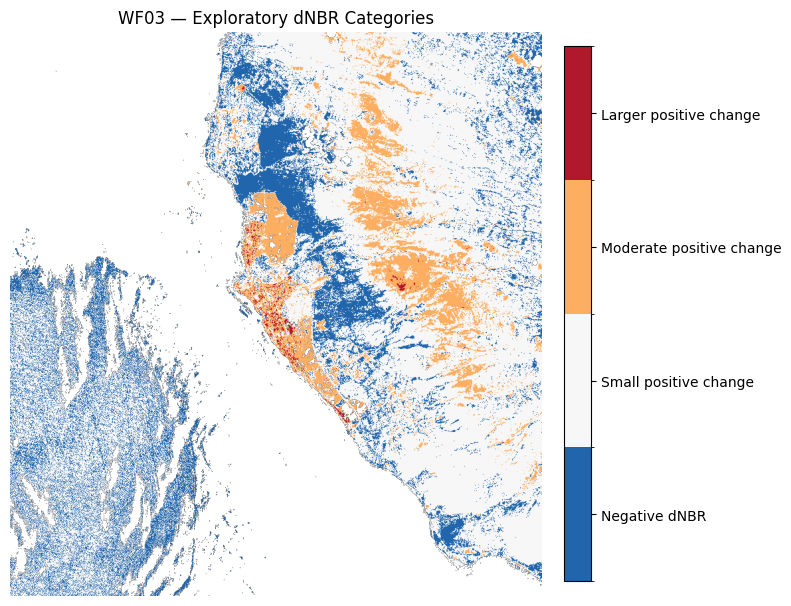

Saved category map: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_dnbr_category_map.png


In [20]:

# Cell 21: Create an exploratory dNBR category map.
#
# Categories:
# 0 = dNBR below 0
# 1 = dNBR from 0 to below 0.10
# 2 = dNBR from 0.10 to below 0.30
# 3 = dNBR at least 0.30
# 255 = invalid/no-data pixel
#
# These categories are for visualization and are not official
# or independently validated burned-area severity classes.

dnbr_categories = np.full(dnbr.shape, 255, dtype=np.uint8)

dnbr_categories[valid_dnbr & (dnbr < 0)] = 0
dnbr_categories[valid_dnbr & (dnbr >= 0) & (dnbr < 0.10)] = 1
dnbr_categories[valid_dnbr & (dnbr >= 0.10) & (dnbr < 0.30)] = 2
dnbr_categories[valid_dnbr & (dnbr >= 0.30)] = 3

category_labels = {
    0: "Negative dNBR",
    1: "Small positive change",
    2: "Moderate positive change",
    3: "Larger positive change"
}

category_rows = []
for category, label in category_labels.items():
    count = int(np.sum(dnbr_categories == category))
    category_rows.append({
        "category_code": category,
        "interpretation": label,
        "pixel_count": count,
        "percent_of_valid_pixels": (
            100 * count / valid_pixel_count if valid_pixel_count else np.nan
        )
    })

category_df = pd.DataFrame(category_rows)
display(category_df)

category_df.to_csv(
    WF03_RESULTS_DIR / "WF03_dnbr_category_counts.csv",
    index=False
)

# Plot the category map.
from matplotlib.colors import ListedColormap, BoundaryNorm

category_colors = ["#2166ac", "#f7f7f7", "#fdae61", "#b2182b"]
category_cmap = ListedColormap(category_colors)
category_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], category_cmap.N)

plot_array = dnbr_categories.astype(float)
plot_array[dnbr_categories == 255] = np.nan

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(plot_array, cmap=category_cmap, norm=category_norm)
ax.set_title("WF03 — Exploratory dNBR Categories")
ax.axis("off")

colorbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], fraction=0.046, pad=0.04)
colorbar.ax.set_yticklabels([category_labels[i] for i in range(4)])

plt.tight_layout()

category_map_path = WF03_RESULTS_DIR / "WF03_dnbr_category_map.png"
plt.savefig(category_map_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved category map:", category_map_path)

In [21]:

# Cell 22: Summarize threshold sensitivity.
# Large differences between thresholds indicate that the estimate
# depends strongly on the chosen threshold.

sensitivity = threshold_df.sort_values("dnbr_threshold").copy()

smallest_area = float(sensitivity["candidate_area_km2_approx"].min())
largest_area = float(sensitivity["candidate_area_km2_approx"].max())

if smallest_area > 0:
    area_ratio = largest_area / smallest_area
else:
    area_ratio = np.nan

sensitivity_summary = pd.DataFrame([{
    "threshold_count": len(sensitivity),
    "lowest_threshold": float(sensitivity["dnbr_threshold"].min()),
    "highest_threshold": float(sensitivity["dnbr_threshold"].max()),
    "minimum_candidate_area_km2": smallest_area,
    "maximum_candidate_area_km2": largest_area,
    "max_to_min_area_ratio": area_ratio,
    "interpretation": (
        "Candidate area changes with threshold; threshold selection matters."
        if largest_area != smallest_area
        else "Candidate area is identical across tested thresholds."
    )
}])

display(sensitivity_summary)

sensitivity_summary.to_csv(
    WF03_RESULTS_DIR / "WF03_threshold_sensitivity_summary.csv",
    index=False
)

print("Saved threshold sensitivity summary.")

,threshold_count,lowest_threshold,highest_threshold,minimum_candidate_area_km2,maximum_candidate_area_km2,max_to_min_area_ratio,interpretation
0,4,0.1,0.4,0.1552,16.6116,107.033505,Candidate area changes with threshold; thresho...


Saved threshold sensitivity summary.


In [22]:

# Cell 23: Generate a conclusion using measured outputs.
# This code deliberately avoids claiming detection accuracy without
# an independent reference burned-area map.

quality_all_passed = bool(quality_df["passed"].all())
valid_percent = 100 * common_valid_mask.mean()
mean_dnbr_value = float(np.nanmean(dnbr))
median_dnbr_value = float(np.nanmedian(dnbr))

threshold_030 = threshold_df.loc[
    np.isclose(threshold_df["dnbr_threshold"], 0.30)
]

if not threshold_030.empty:
    area_030 = float(threshold_030.iloc[0]["candidate_area_km2_approx"])
    pixels_030 = int(threshold_030.iloc[0]["candidate_pixels"])
else:
    area_030 = None
    pixels_030 = None

conclusion_lines = [
    "# WF03 — NBR/dNBR Burned-Area Baseline Conclusion",
    "",
    "## Experiment setup",
    f"- Event: {EVENT_NAME}",
    f"- Pre-fire scene ID: {pre_item.id}",
    f"- Pre-fire acquisition: {pre_item.datetime}",
    f"- Post-fire scene ID: {post_item.id}",
    f"- Post-fire acquisition: {post_item.datetime}",
    f"- Days between scenes: {date_gap_days}",
    "",
    "## Observed results",
    f"- Common valid pixels: {int(common_valid_mask.sum()):,} / {int(common_valid_mask.size):,}",
    f"- Common valid coverage: {valid_percent:.2f}%",
    f"- Mean dNBR: {mean_dnbr_value:.4f}",
    f"- Median dNBR: {median_dnbr_value:.4f}",
    f"- Minimum dNBR: {float(np.nanmin(dnbr)):.4f}",
    f"- Maximum dNBR: {float(np.nanmax(dnbr)):.4f}",
]

if pixels_030 is not None:
    conclusion_lines += [
        f"- Candidate pixels with dNBR >= 0.30: {pixels_030:,}",
        f"- Approximate candidate area at dNBR >= 0.30: {area_030:.3f} km²"
    ]

conclusion_lines += [
    "",
    "## Quality checks",
    f"- All automated checks passed: {quality_all_passed}",
    "- Automated checks do not replace manual imagery inspection.",
    "",
    "## Conclusion",
    "",
    "The experiment produced a pre-fire/post-fire NBR comparison and a dNBR-based",
    "threshold-sensitivity baseline for the selected pilot area.",
    "Positive dNBR identifies candidate spectral changes, not independently confirmed burned land.",
    "The estimated candidate area depends on the threshold and the quality of the selected scenes.",
    "",
    "## Limitations",
    "",
    "- The study window is not an official wildfire perimeter.",
    "- Scene-wide cloud percentage does not guarantee a cloud-free study area.",
    "- Clouds, shadows, smoke, urban surfaces, soil moisture, and other land-cover changes can affect dNBR.",
    "- Thresholds have not been validated against an independent burn-area reference.",
    "- No precision, recall, IoU, or accuracy claim is justified without independent reference labels.",
    "",
    "## Artifacts",
    "",
    "- `WF03_NBR_dNBR_visualization.png`",
    "- `WF03_dnbr_category_map.png`",
    "- `WF03_threshold_sensitivity.csv`",
    "- `WF03_scene_and_coverage_summary.csv`",
    "- `WF03_research_quality_checks.csv`",
    "- `WF03_output_verification.csv`"
]

conclusion_path = WF03_RESULTS_DIR / "WF03_conclusion.md"
conclusion_path.write_text("\n".join(conclusion_lines), encoding="utf-8")

print("Conclusion saved:", conclusion_path)
print(conclusion_path.read_text(encoding="utf-8"))

Conclusion saved: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_conclusion.md
# WF03 — NBR/dNBR Burned-Area Baseline Conclusion

## Experiment setup
- Event: Lahaina_Hawaii_2023
- Pre-fire scene ID: S2A_MSIL2A_20230803T210931_R057_T04QGJ_20240823T144936
- Pre-fire acquisition: 2023-08-03 21:09:31.024000+00:00
- Post-fire scene ID: S2B_MSIL2A_20230907T210929_R057_T04QGJ_20230908T042719
- Post-fire acquisition: 2023-09-07 21:09:29.024000+00:00
- Days between scenes: 34

## Observed results
- Common valid pixels: 398,857 / 681,651
- Common valid coverage: 58.51%
- Mean dNBR: 0.0366
- Median dNBR: 0.0257
- Minimum dNBR: -0.4824
- Maximum dNBR: 0.6275
- Candidate pixels with dNBR >= 0.30: 1,467
- Approximate candidate area at dNBR >= 0.30: 0.587 km²

## Quality checks
- All automated checks passed: True
- Automated checks do not replace manual imagery inspection.

## Conclusion

The experiment produced a pre-fire/post-fire NBR comparison and a dNBR-based
threshold-sensitivity base

In [23]:

# Cell 24: Verify all expected WF03 files, including the final analysis.
# This cell must be run after Cells 20–23.

final_expected_outputs = [
    "WF03_configuration.json",
    "WF03_candidate_scenes.csv",
    "WF03_selected_scenes.csv",
    "WF03_selected_scene_ids.txt",
    "WF03_scl_class_distribution.csv",
    "WF03_valid_pixel_summary.csv",
    "WF03_pre_fire_NBR.tif",
    "WF03_post_fire_NBR.tif",
    "WF03_dnbr_summary.csv",
    "WF03_dNBR.tif",
    "WF03_NBR_dNBR_visualization.png",
    "WF03_threshold_sensitivity.csv",
    "WF03_threshold_sensitivity.png",
    "WF03_candidate_change_0p10.tif",
    "WF03_candidate_change_0p20.tif",
    "WF03_candidate_change_0p30.tif",
    "WF03_candidate_change_0p40.tif",
    "WF03_scene_and_coverage_summary.csv",
    "WF03_research_quality_checks.csv",
    "WF03_dnbr_category_counts.csv",
    "WF03_dnbr_category_map.png",
    "WF03_threshold_sensitivity_summary.csv",
    "WF03_summary.md",
    "WF03_conclusion.md"
]

final_audit_rows = []

for filename in final_expected_outputs:
    path = WF03_RESULTS_DIR / filename
    exists = path.is_file()
    size = path.stat().st_size if exists else 0

    final_audit_rows.append({
        "filename": filename,
        "exists": exists,
        "size_bytes": size,
        "status": "OK" if exists and size > 0 else "MISSING_OR_EMPTY"
    })

final_audit_df = pd.DataFrame(final_audit_rows)
display(final_audit_df)

final_audit_path = WF03_RESULTS_DIR / "WF03_final_output_audit.csv"
final_audit_df.to_csv(final_audit_path, index=False)

missing_files = final_audit_df.loc[
    final_audit_df["status"] != "OK", "filename"
].tolist()

if missing_files:
    print("WF03 is not yet complete. Missing or empty files:")
    for filename in missing_files:
        print("-", filename)
else:
    print("All listed WF03 outputs exist and are non-empty.")

print("Final audit saved:", final_audit_path)
print("WF03 output directory:", WF03_RESULTS_DIR)

,filename,exists,size_bytes,status
0,WF03_configuration.json,True,449,OK
1,WF03_candidate_scenes.csv,True,4970,OK
2,WF03_selected_scenes.csv,True,267,OK
3,WF03_selected_scene_ids.txt,True,246,OK
4,WF03_scl_class_distribution.csv,False,0,MISSING_OR_EMPTY
5,WF03_valid_pixel_summary.csv,True,136,OK
6,WF03_pre_fire_NBR.tif,True,2729837,OK
7,WF03_post_fire_NBR.tif,True,2729837,OK
8,WF03_dnbr_summary.csv,True,178,OK
9,WF03_dNBR.tif,True,2729837,OK


WF03 is not yet complete. Missing or empty files:
- WF03_scl_class_distribution.csv
- WF03_candidate_change_0p10.tif
- WF03_candidate_change_0p20.tif
- WF03_candidate_change_0p30.tif
- WF03_candidate_change_0p40.tif
Final audit saved: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_final_output_audit.csv
WF03 output directory: /content/wildfire_monitoring/results/WF03_nbr_dnbr


In [24]:

# Cell 25: Create a manifest of the WF03 research artifacts.
#
# Purpose:
# 1. List every file produced by WF03.
# 2. Record file sizes and SHA-256 checksums.
# 3. Make it easier to verify that artifacts have not changed.
#
# Note:
# This creates a manifest; it does not automatically upload or commit files
# to GitHub.

import hashlib
from datetime import datetime, timezone

def calculate_sha256(file_path):
    """Calculate a file's SHA-256 checksum in manageable chunks."""
    digest = hashlib.sha256()

    with open(file_path, "rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)

    return digest.hexdigest()

manifest_rows = []

for file_path in sorted(WF03_RESULTS_DIR.iterdir()):
    # Include only files, not subdirectories.
    if not file_path.is_file():
        continue

    # Skip the manifest itself so it does not attempt to checksum itself.
    if file_path.name == "WF03_artifact_manifest.csv":
        continue

    manifest_rows.append({
        "filename": file_path.name,
        "size_bytes": file_path.stat().st_size,
        "sha256": calculate_sha256(file_path),
        "recorded_at_utc": datetime.now(timezone.utc).isoformat()
    })

manifest_df = pd.DataFrame(manifest_rows)

manifest_path = WF03_RESULTS_DIR / "WF03_artifact_manifest.csv"
manifest_df.to_csv(manifest_path, index=False)

print("WF03 artifact manifest created.")
print("Files catalogued:", len(manifest_df))
print("Manifest path:", manifest_path)

display(manifest_df[["filename", "size_bytes"]])

WF03 artifact manifest created.
Files catalogued: 25
Manifest path: /content/wildfire_monitoring/results/WF03_nbr_dnbr/WF03_artifact_manifest.csv


,filename,size_bytes
0,WF03_NBR_dNBR_visualization.png,2793002
1,WF03_candidate_change_0p1.tif,682844
2,WF03_candidate_change_0p2.tif,682844
3,WF03_candidate_change_0p3.tif,682844
4,WF03_candidate_change_0p4.tif,682844
5,WF03_candidate_scenes.csv,4970
6,WF03_conclusion.md,1794
7,WF03_configuration.json,449
8,WF03_dNBR.tif,2729837
9,WF03_dnbr_category_counts.csv,255
